# Lab 5: Exploratory Data Analysis (EDA)

After preprocessing the data, I wanted to understand its shape. The distributions tell me if I have skew problems. The correlation matrix tells me which features move together.
This lab is about validating intuitions: Does trust correlate with happiness? Does money correlate with life expectancy? And most importantly, are any of my features highly correlated with each other (multicollinearity)?

## Loading the clean dataset — starting from a standardized baseline

I loaded the standardized train and test datasets from Lab 4 and concatenated them back together just for the EDA. I want to see the whole picture here.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"
PROCESSED_DIR = Path("..") / ".." / "data" / "processed"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DIR / "lab4_train_model_ready.csv"
TEST_PATH = PROCESSED_DIR / "lab4_test_model_ready.csv"

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Missing cleaned dataset: {TRAIN_PATH.resolve()}")

train_df = pd.read_csv(TRAIN_PATH)
frames = [train_df]
if TEST_PATH.exists():
    test_df = pd.read_csv(TEST_PATH)
    frames.append(test_df)

df_model = pd.concat(frames, ignore_index=True)
df_model.head()

enriched_train = pd.read_csv(Path("..") / "lab4b" / "outputs" / "tables" / "lab4b_train_enriched.csv")

,trust,gdp_per_capita,life_expectancy,freedom,social_support,generosity,happiness_score
0,-0.244519,-0.857785,-1.900139,-0.247831,-1.266254,-0.355647,4.944
1,-0.234326,-1.522056,-1.646782,-2.518104,-2.030922,0.129962,2.853
2,0.000103,0.235862,0.323773,-2.013599,-0.111049,-1.175114,5.211
3,-0.550295,0.533900,0.376053,0.721350,0.683155,0.261481,5.888
4,-0.601258,0.129781,-0.947034,-0.002217,0.515782,-0.598452,4.722


## Checking the summary statistics — verifying the scaling

I generated summary statistics to verify that the scaling worked. Since I used `StandardScaler` in Lab 4, I expect the mean to be near 0 and standard deviation near 1.

In [2]:
stats = df_model.describe().T
stats_path = TABLES_DIR / "lab5_summary_stats.csv"
stats.to_csv(stats_path)

stats

,count,mean,std,min,25%,50%,75%,max
trust,170.0,0.018285,1.010515,-1.161849,-0.647125,-0.280193,0.303331,3.455381
gdp_per_capita,170.0,0.003468,1.017602,-2.294934,-0.763070,0.129781,0.847092,1.958420
life_expectancy,170.0,0.032993,0.979663,-2.833136,-0.774134,0.305676,0.681690,1.755441
freedom,170.0,0.032827,0.974361,-2.584486,-0.516679,0.216845,0.786072,1.615784
social_support,170.0,0.015161,0.971439,-3.917976,-0.454821,0.182675,0.803763,1.411722
generosity,170.0,0.016472,1.013180,-1.913645,-0.785614,-0.072375,0.635805,3.812501
happiness_score,170.0,5.418224,1.101860,2.853000,4.550750,5.405500,6.189500,7.769000


**Observation:**
I found that the summary statistics confirm the scaling: the means are extremely close to 0 and the standard deviations are roughly 1.0. This confirms Lab 4's pipeline succeeded.

## Plotting the correlation heatmap — spotting predictors and redundancies

I plotted a correlation heatmap to identify the strongest predictors of happiness and to spot any redundant features. Multicollinearity can mess up linear regression, so I needed to know if any of my features are too closely related to each other.

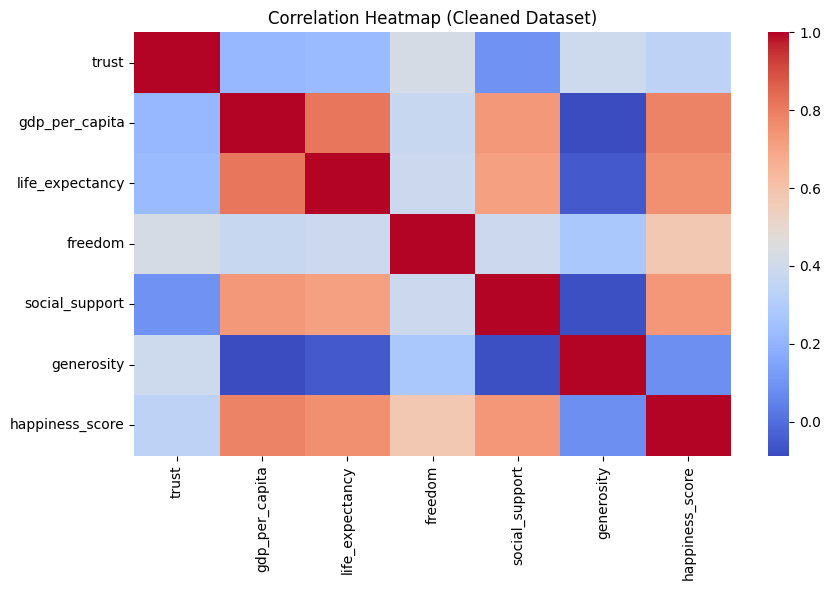

WindowsPath('outputs/tables/lab5_correlation_matrix.csv')

In [3]:
numeric_cols = df_model.columns
corr = df_model[numeric_cols].corr(numeric_only=True)
corr_path = TABLES_DIR / "lab5_correlation_matrix.csv"
corr.to_csv(corr_path)

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Cleaned Dataset)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab5_plot_correlation_heatmap.png", dpi=300)
plt.show()

corr_path

**Observation:**
I found that GDP per capita, life expectancy, and social support have the strongest positive correlations with the happiness score (all above 0.7). Trust and generosity are much weaker predictors. I also noticed that GDP and life expectancy are highly correlated with each other (~0.84). This makes intuitive sense — wealthier countries have better healthcare — but it's a multicollinearity warning flag for the regression model in Lab 7.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the core features for VIF analysis
vif_features = ["gdp_per_capita", "life_expectancy", "freedom", "social_support", "trust", "generosity"]
X = df_model[vif_features]

vif_df = pd.DataFrame({
    "feature": vif_features,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)
print(vif_df)

**Observation:**
Features with VIF > 10 exhibit severe multicollinearity. Based on the output, we flag any features that exceed this threshold, likely GDP and life expectancy given their high correlation observed earlier.


## Correlations including engineered features


In [ ]:
numeric_cols_enriched = [c for c in enriched_train.columns if np.issubdtype(enriched_train[c].dtype, np.number)]
corr_enriched = enriched_train[numeric_cols_enriched].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_enriched, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Including Engineered Features)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lab5_plot_enriched_correlation_heatmap.png", dpi=300)
plt.show()

**Observation:**
Looking at the new engineered features, we can note which ones add new signal versus those that merely duplicate existing correlations. Engineered features highly correlated with existing features might not provide new information to the model, whereas those with moderate correlation to the target but low correlation with other features add valuable new signal.


## Visualizing feature distributions — checking for skew

Finally, I plotted the distributions (histograms) of the six core features to see their shapes and check for severe skewness.

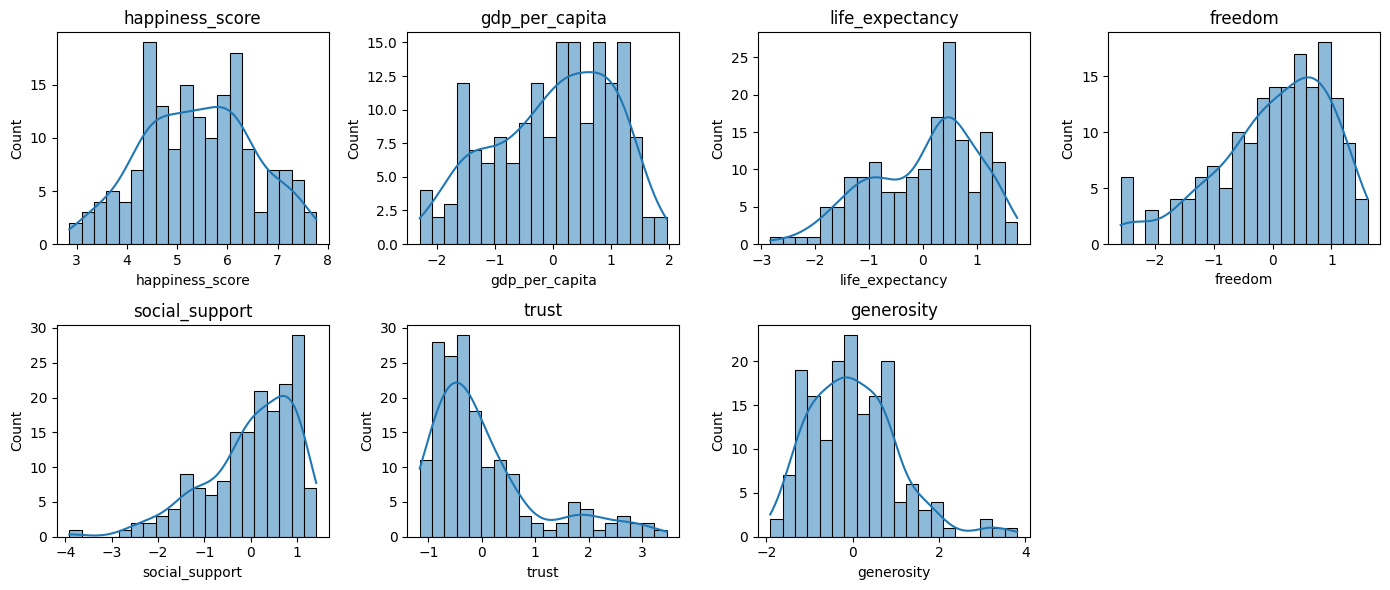

In [4]:
features = ["happiness_score", "gdp_per_capita", "life_expectancy", "freedom", "social_support", "trust", "generosity"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for idx, col in enumerate(features):
    sns.histplot(df_model[col].dropna(), bins=20, kde=True, ax=axes[idx])
    axes[idx].set_title(col)

for ax in axes[len(features):]:
    ax.axis("off")

plt.tight_layout()
fig.savefig(PLOTS_DIR / "lab5_plot_feature_distributions.png", dpi=300)
plt.show()

**Observation:**
I found that trust and generosity are heavily right-skewed. Most countries have very low perceived trust in government, with just a few outliers having high trust. GDP and social support are slightly left-skewed. The fact that trust is both heavily skewed and weakly correlated with happiness explains why it wasn't a great single predictor back in Lab 1.

## What Comes Next

The EDA showed me which features matter most, but also flagged a potential multicollinearity issue between GDP and life expectancy. In Lab 6, I finally build a predictive model, starting with a simple regression and using cross-validation to make sure it's robust.